In [91]:
import os
import pickle
from data.custom_dataset import DataFrameStore, CustomDataLoader

data_root = "data/processed"

print(f"====Loading processed dataset====\n\n")
with open(os.path.join(data_root, "processed_dataset.pkl"), "rb") as f:
    dataset = pickle.load(f)

features_dict = dataset.features_dict
labels_dict = dataset.labels_dict

print(f"Features: {dataset.feature_stn_names}")
print(f"Labels: {dataset.label_stn_names}")

====Loading processed dataset====


Features: ['ST3_PRESS', 'ST4_INROLL']
Labels: ['ST7_ROTATING']


In [92]:
# Resample / plotting configs
configs = {
    "target_len":100,
    "num_samples_to_plot": 5,
    "save_path": "data/processed"
}

In [93]:
import matplotlib.pyplot as plt
import numpy as np

def resample_features(features_dict, target_len=100, max_samples=configs["num_samples_to_plot"], station_name:str="ST4_INROLL"):

    # st3
    x = []
    y = []

    x_orig=[]
    y_orig=[]
    for sample_id in features_dict[station_name]['Position(mm)']:
        _x = features_dict[station_name]['Position(mm)'][sample_id]['data']
        _y = features_dict[station_name]['Load(N)'][sample_id]['data']

        """ # resample to target_len
        x_new = np.linspace(np.min(_x), np.max(_x), target_len) #NOTE: does not catch scenario where press moves back in position
        y_new = np.interp(
                x_new,
                _x,
                _y
            ) """
        
        # Compute cumulative distance along the path
        # Use cumulative distance (arc length) instead of x-position for resampling
        # This is more robust for paths that loop, reverse, or are not 1D.
        diffs = np.diff(_x)
        dists = np.insert(np.cumsum(np.abs(diffs)), 0, 0)  # cumulative distance

        # Create uniform distance spacing for target length
        dists_new = np.linspace(dists[0], dists[-1], target_len)

        # Interpolate based on distance instead of x
        x_new = np.interp(dists_new, dists, _x)
        y_new = np.interp(dists_new, dists, _y)

       
        x.append(x_new)
        y.append(y_new)

        x_orig.append(_x)
        y_orig.append(_y)

    
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    for px, py in list(zip(x, y))[:max_samples]:
        axs[0].plot(px, py, alpha=0.3, color='#333333')
    
    axs[0].set_title(f"[Resampled {target_len} pts] {station_name}: Position(mm) vs Load(N)")
    axs[0].set_xlabel("Position(mm)")
    axs[0].set_ylabel("Load(N)")
    #axs[0].set_ylim([2900, 3150])

    for px, py in list(zip(x_orig, y_orig))[:max_samples]:
        axs[1].plot(px, py, alpha=0.3, color='#333333')
    
    axs[1].set_title(f"[Original] {station_name}: Position(mm) vs Load(N)")
    axs[1].set_xlabel("Position(mm)")
    axs[1].set_ylabel("Load(N)")


    return (x, y)

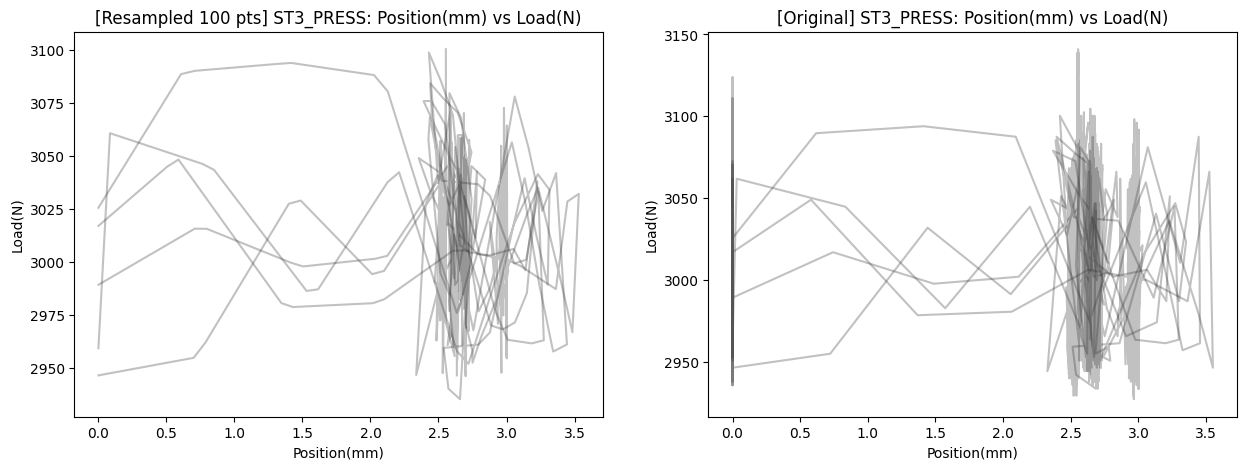

In [94]:
st3 = resample_features(features_dict, target_len=configs['target_len'], station_name="ST3_PRESS")

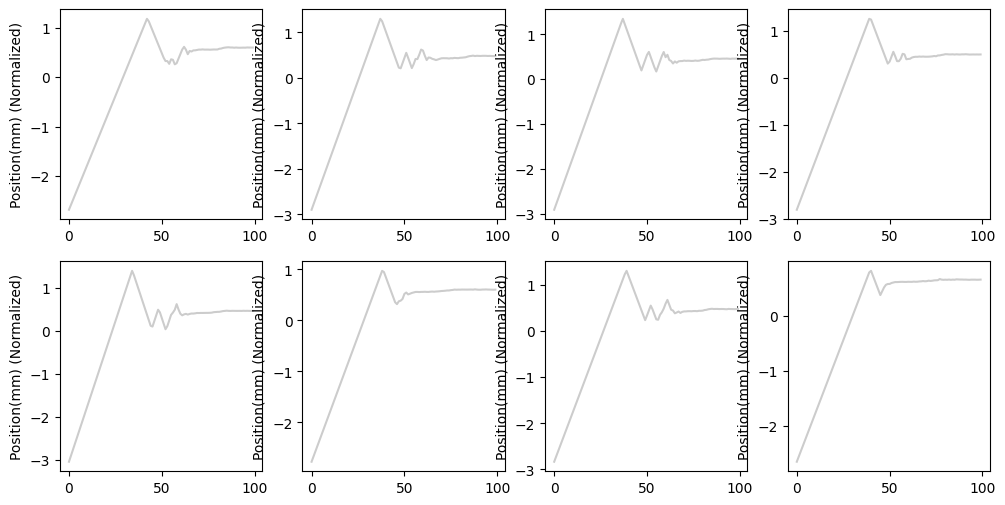

In [95]:
# Z-Normalize the data
#   - Standardizes each time series by:
#     - Subtracting the mean
#     - Dividing by the standard deviation
#   - Each time series has:
#     - Mean = 0
#     - Standard deviation = 1

from tslearn.preprocessing import TimeSeriesScalerMeanVariance

st3_x = st3[0]
normalized_st3_x = TimeSeriesScalerMeanVariance().fit_transform(st3_x)
plt.figure(figsize=(12, 6))
for yi in range(8):
    plt.subplot(2, 4, yi + 1)
    plt.plot(normalized_st3_x[yi].ravel(), "k-", alpha=.2)
    plt.ylabel("Position(mm) (Normalized)")

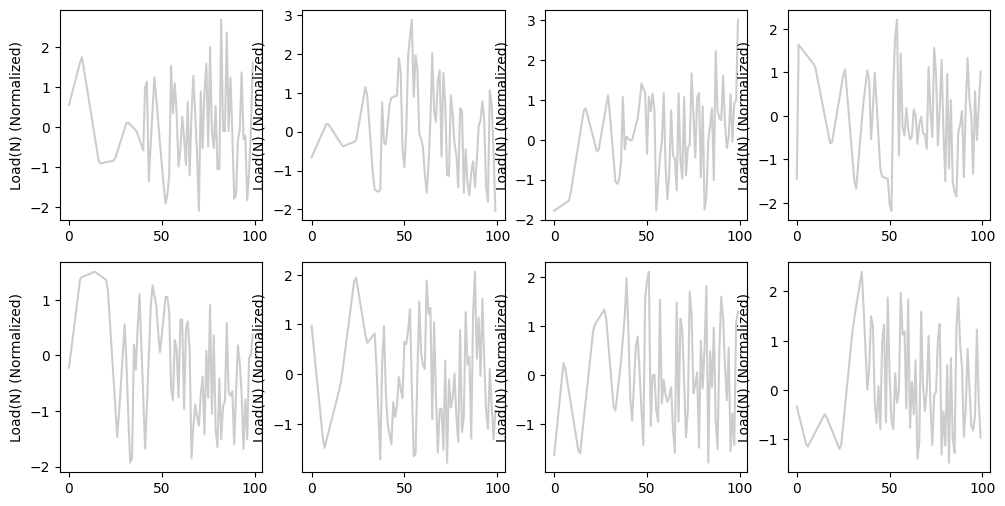

In [96]:

st3_y = st3[1]
normalized_st3_y = TimeSeriesScalerMeanVariance().fit_transform(st3_y)
plt.figure(figsize=(12, 6))
for yi in range(8):
    plt.subplot(2, 4, yi + 1)
    plt.plot(normalized_st3_y[yi].ravel(), "k-", alpha=.2)
    plt.ylabel("Load(N) (Normalized)")

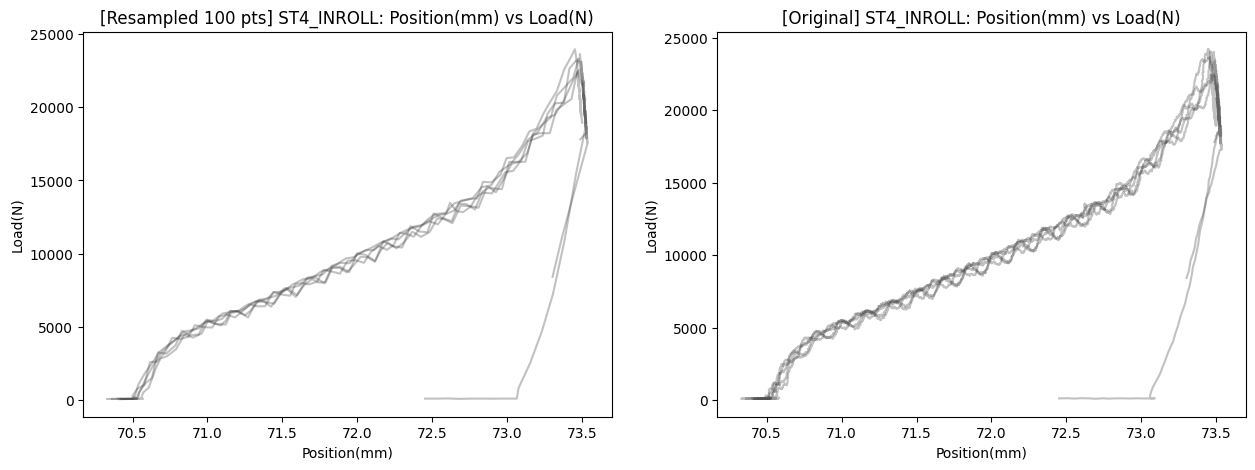

In [97]:
st4 = resample_features(features_dict, target_len=configs['target_len'], station_name="ST4_INROLL")

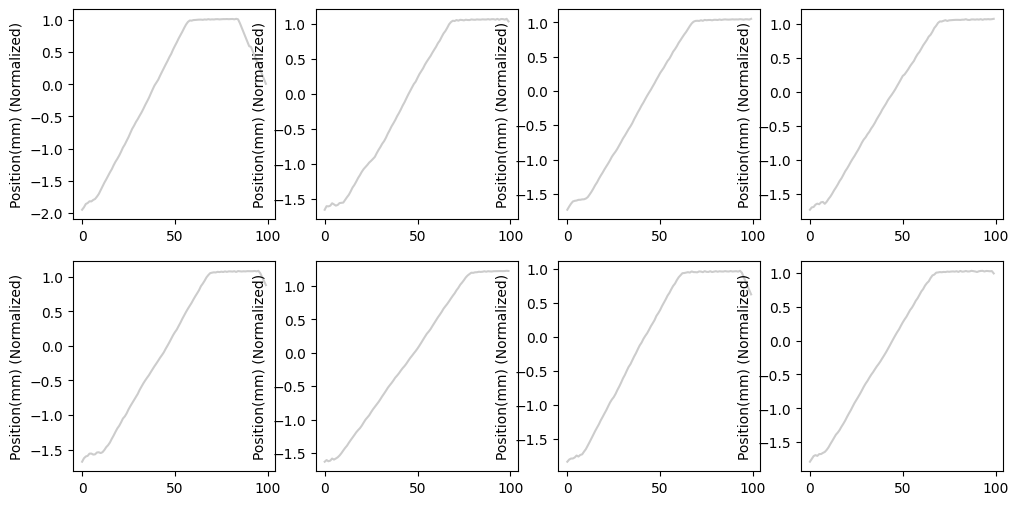

In [98]:
st4_x = st4[0]
normalized_st4_x = TimeSeriesScalerMeanVariance().fit_transform(st4_x)
plt.figure(figsize=(12, 6))
for yi in range(8):
    plt.subplot(2, 4, yi + 1)
    plt.plot(normalized_st4_x[yi].ravel(), "k-", alpha=.2)
    plt.ylabel("Position(mm) (Normalized)")

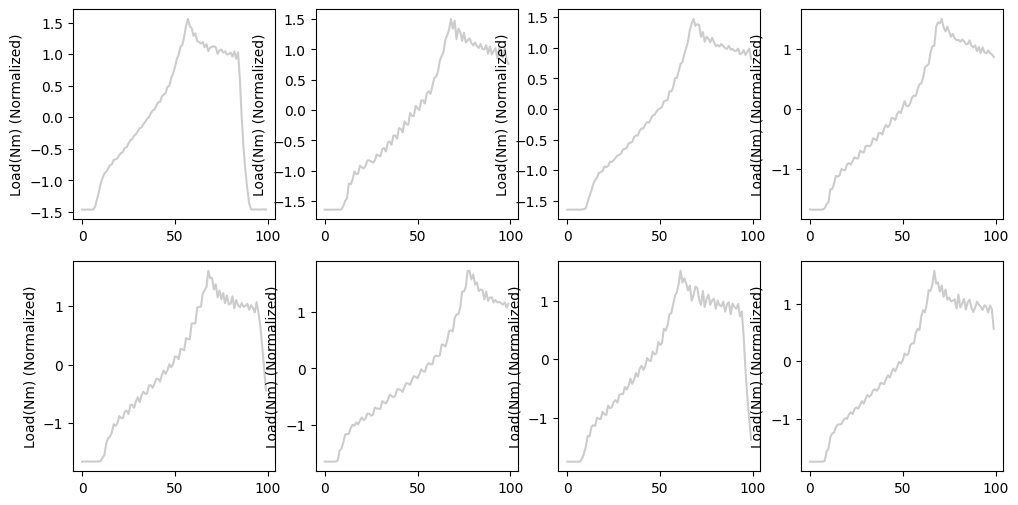

In [99]:
st4_y = st4[1]
normalized_st4_y = TimeSeriesScalerMeanVariance().fit_transform(st4_y)
plt.figure(figsize=(12, 6))
for yi in range(8):
    plt.subplot(2, 4, yi + 1)
    plt.plot(normalized_st4_y[yi].ravel(), "k-", alpha=.2)
    plt.ylabel("Load(Nm) (Normalized)")

In [100]:
import numpy 
from tslearn.clustering import TimeSeriesKMeans, silhouette_score

seed = 0
np.random.seed(seed)
num_samples = 100

X_train_st4_y = TimeSeriesScalerMeanVariance().fit_transform(st4_y[:num_samples])
sz_st4_y = X_train_st4_y.shape[1]

X_train_st4_x = TimeSeriesScalerMeanVariance().fit_transform(st4_x[:num_samples])
sz_st4_x = X_train_st4_x.shape[1]

X_train_st3_x = TimeSeriesScalerMeanVariance().fit_transform(st3_x[:num_samples])
sz_st3_x = X_train_st3_x.shape[1]

X_train_st3_y = TimeSeriesScalerMeanVariance().fit_transform(st3_y[:num_samples])
sz_st3_y = X_train_st3_y.shape[1]


In [101]:
""" sum_of_squared_distances_st4_y = []
K = range(2,8)
for k in K:
    km = TimeSeriesKMeans(n_clusters=k,
                          n_init=2,
                          metric="dtw",
                          verbose=False,
                          max_iter_barycenter=10,
                          random_state=0)
    
    km = km.fit(X_train_st4_y)
    sum_of_squared_distances_st4_y.append(km.inertia_) """

' sum_of_squared_distances_st4_y = []\nK = range(2,8)\nfor k in K:\n    km = TimeSeriesKMeans(n_clusters=k,\n                          n_init=2,\n                          metric="dtw",\n                          verbose=False,\n                          max_iter_barycenter=10,\n                          random_state=0)\n    \n    km = km.fit(X_train_st4_y)\n    sum_of_squared_distances_st4_y.append(km.inertia_) '

In [102]:
""" plt.plot(K, sum_of_squared_distances_st4_y, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show() """

" plt.plot(K, sum_of_squared_distances_st4_y, 'bx-')\nplt.xlabel('k')\nplt.ylabel('Sum_of_squared_distances')\nplt.title('Elbow Method For Optimal k')\nplt.show() "

DBA k-means
DBA silhoutte: 0.75


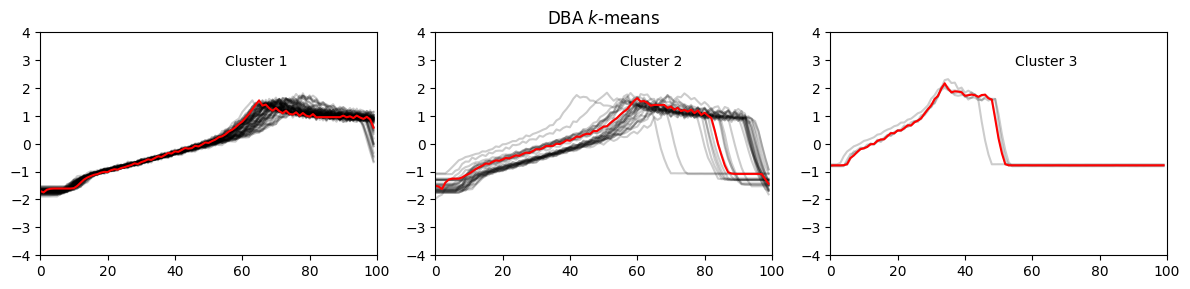

In [115]:
n_clusters = 3
X_train = X_train_st4_y
sz = X_train.shape[1]

# DBA-k-means
print("DBA k-means")
dba_km = TimeSeriesKMeans(n_clusters=n_clusters,
                          n_init=2,
                          metric="dtw",
                          verbose=False,
                          max_iter_barycenter=10,
                          random_state=seed)
y_pred_dba_km = dba_km.fit_predict(X_train)
print("DBA silhoutte: {:.2f}".format(silhouette_score(X_train, y_pred_dba_km, metric="dtw")))



plt.figure(figsize=(12, 8))
for yi in range(n_clusters):
    plt.subplot(3, n_clusters, yi+1)
    for xx in X_train[y_pred_dba_km == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(dba_km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("DBA $k$-means")


plt.tight_layout()
plt.show()

DBA k-means
DBA silhoutte: 0.79


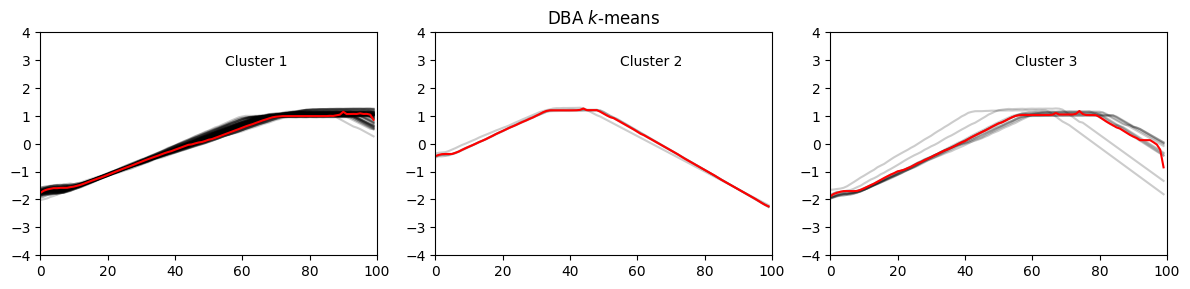

In [116]:
n_clusters = 3
X_train = X_train_st4_x
sz = X_train.shape[1]

# DBA-k-means
print("DBA k-means")
dba_km = TimeSeriesKMeans(n_clusters=n_clusters,
                          n_init=2,
                          metric="dtw",
                          verbose=False,
                          max_iter_barycenter=10,
                          random_state=seed)
y_pred_dba_km = dba_km.fit_predict(X_train)
print("DBA silhoutte: {:.2f}".format(silhouette_score(X_train, y_pred_dba_km, metric="dtw")))



plt.figure(figsize=(12, 8))
for yi in range(n_clusters):
    plt.subplot(3, n_clusters, yi+1)
    for xx in X_train[y_pred_dba_km == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(dba_km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("DBA $k$-means")


plt.tight_layout()
plt.show()

DBA k-means
DBA silhoutte: 0.48


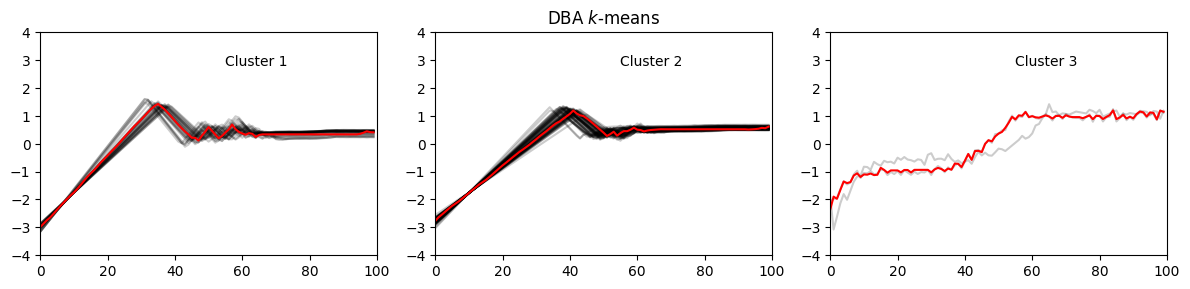

In [117]:
n_clusters = 3
X_train = X_train_st3_x
sz = X_train.shape[1]

# DBA-k-means
print("DBA k-means")
dba_km = TimeSeriesKMeans(n_clusters=n_clusters,
                          n_init=2,
                          metric="dtw",
                          verbose=False,
                          max_iter_barycenter=10,
                          random_state=seed)
y_pred_dba_km = dba_km.fit_predict(X_train)
print("DBA silhoutte: {:.2f}".format(silhouette_score(X_train, y_pred_dba_km, metric="dtw")))



plt.figure(figsize=(12, 8))
for yi in range(n_clusters):
    plt.subplot(3, n_clusters, yi+1)
    for xx in X_train[y_pred_dba_km == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(dba_km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("DBA $k$-means")


plt.tight_layout()
plt.show()

DBA k-means
DBA silhoutte: 0.05


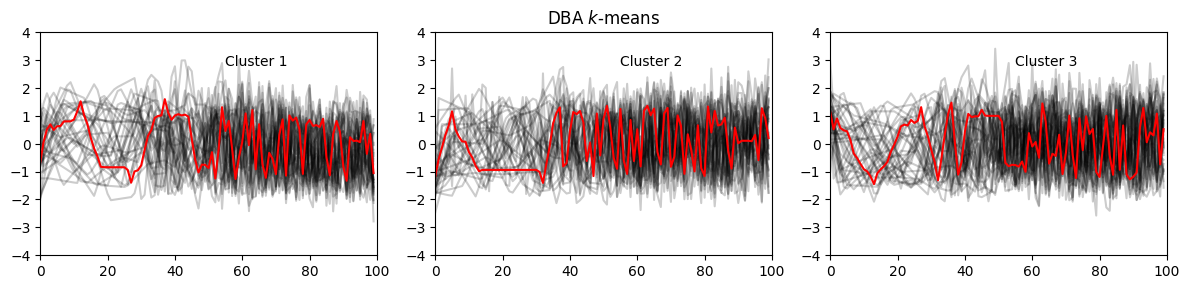

In [118]:
n_clusters = 3
X_train = X_train_st3_y
sz = X_train.shape[1]

# DBA-k-means
print("DBA k-means")
dba_km = TimeSeriesKMeans(n_clusters=n_clusters,
                          n_init=2,
                          metric="dtw",
                          verbose=False,
                          max_iter_barycenter=10,
                          random_state=seed)
y_pred_dba_km = dba_km.fit_predict(X_train)
print("DBA silhoutte: {:.2f}".format(silhouette_score(X_train, y_pred_dba_km, metric="dtw")))



plt.figure(figsize=(12, 8))
for yi in range(n_clusters):
    plt.subplot(3, n_clusters, yi+1)
    for xx in X_train[y_pred_dba_km == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(dba_km.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, sz)
    plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi + 1),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("DBA $k$-means")


plt.tight_layout()
plt.show()

In [ ]:
""" # Save DBA-k-means model and predictions
from pathlib import Path
import json
import numpy as np
import joblib

save_dir = Path("experiments/dbscan_dba_kmeans")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / f"dba_km_nclust{n_clusters}_seed{seed}.joblib"
preds_path = save_dir / f"y_pred_nclust{n_clusters}_seed{seed}.npy"
meta_path = save_dir / f"meta_nclust{n_clusters}_seed{seed}.json"

# Save model and predictions
joblib.dump(dba_km, model_path)
np.save(preds_path, y_pred_dba_km)

# Save simple metadata
sil_val = float(silhouette_score(X_train_st4_y, y_pred_dba_km, metric="dtw"))
meta = {
    "n_clusters": int(n_clusters),
    "seed": int(seed),
    "silhouette": sil_val,
}
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved model to: {model_path}")
print(f"Saved predictions to: {preds_path}")
print(f"Saved metadata to: {meta_path}") """
